# Project 7 — Conditional DDPM: linear vs cosine noise schedule

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import utils

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Hyper-parameters

In [3]:
SEED = 0
timesteps = 1000          # T, the same for both schedules
epochs = 150              # as in the 9.3 tutorial solution
bs_train = 128
bs_test = 128
lr = 2e-4
n_channels_unet = 32
n_class = 10

CKPT_DIR = 'checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

## Setup the custom MNIST dataset
`mnist_custom.pt` is a dictionary of four tensors (train/test images and labels). Inspect it first, then build `TensorDataset`s scaled to [-1, 1] as in the tutorial.

In [4]:
data = torch.load('mnist_custom.pt')
for k, v in data.items():
    if torch.is_tensor(v):
        print(f"{k:>15}: shape={tuple(v.shape)}, dtype={v.dtype}, min={v.min().item():.3f}, max={v.max().item():.3f}")
    else:
        print(k, type(v))

   train_images: shape=(60000, 1, 20, 20), dtype=torch.float32, min=0.000, max=1.000
   train_labels: shape=(60000,), dtype=torch.int64, min=0.000, max=9.000
    test_images: shape=(10000, 1, 20, 20), dtype=torch.float32, min=0.000, max=1.000
    test_labels: shape=(10000,), dtype=torch.int64, min=0.000, max=9.000


In [5]:
def find_split(data, split):
    """Find the image tensor (>=3 dims) and label tensor (1 dim) whose key contains `split`."""
    imgs, labels = None, None
    for k, v in data.items():
        if split in k.lower() and torch.is_tensor(v):
            if v.dim() >= 3:
                imgs = v
            elif v.dim() == 1:
                labels = v
    assert imgs is not None and labels is not None, (
        f"Could not find the '{split}' tensors automatically in keys {list(data.keys())}. "
        "Set them manually in this cell.")
    return imgs, labels

def to_dataset(x, y):
    """Scale images to [-1, 1] (as in the tutorial) and add the channel dimension."""
    x = x.float()
    if x.min() >= 0:              # not already in [-1, 1]
        if x.max() > 1:
            x = x / 255.0         # uint8 [0, 255] -> [0, 1]
        x = x * 2 - 1             # [0, 1] -> [-1, 1]
    if x.dim() == 3:
        x = x.unsqueeze(1)        # (N, 28, 28) -> (N, 1, 28, 28)
    return TensorDataset(x, y.long())

x_train, y_train = find_split(data, 'train')
x_test, y_test = find_split(data, 'test')

train_dataset = to_dataset(x_train, y_train)
test_dataset = to_dataset(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=bs_test, shuffle=False)

print("train:", train_dataset.tensors[0].shape, "range", train_dataset.tensors[0].min().item(), train_dataset.tensors[0].max().item())
print("test: ", test_dataset.tensors[0].shape)

# the custom dataset is not necessarily 28x28: take the size from the data
image_size = train_dataset.tensors[0].shape[-1]
assert train_dataset.tensors[0].shape[-2] == image_size, "expected square images"
assert image_size % 4 == 0, f"U-Net pools twice, so image_size must be divisible by 4 (got {image_size})"
print("image_size:", image_size)
print("class counts (train):", torch.bincount(train_dataset.tensors[1], minlength=10).tolist())

train: torch.Size([60000, 1, 20, 20]) range -1.0 1.0
test:  torch.Size([10000, 1, 20, 20])
image_size: 20
class counts (train): [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]


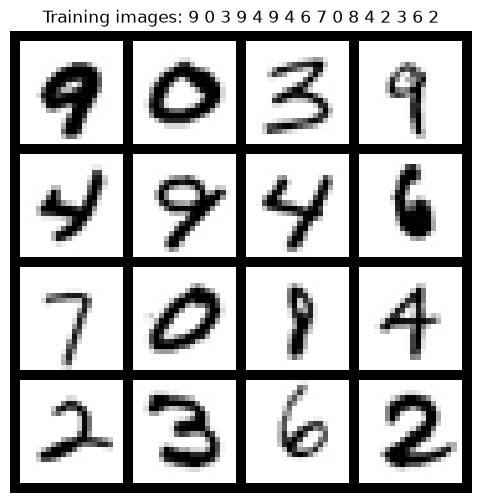

In [6]:
imgs, labels = next(iter(DataLoader(train_dataset, batch_size=16, shuffle=True)))
plt.figure(figsize=(6, 6))
plt.imshow(utils.make_grid((imgs + 1) / 2, nrow=4).permute(1, 2, 0))
plt.title('Training images: ' + ' '.join(str(l.item()) for l in labels))
plt.axis('off')
plt.show()

## Forward diffusion process: linear vs cosine schedule

The linear schedule increases $\beta_t$ linearly from $10^{-4}$ to $0.02$. The cosine schedule (Nichol & Dhariwal, 2021) instead defines the cumulative signal directly:

$$\bar\alpha_t = \frac{f(t)}{f(0)}, \qquad f(t) = \cos^2\!\left(\frac{t/T + s}{1+s}\cdot\frac{\pi}{2}\right), \qquad \beta_t = 1 - \frac{\bar\alpha_t}{\bar\alpha_{t-1}}$$

with $s = 0.008$, and $\beta_t$ clipped to at most $0.999$. Each schedule is stored in its own dictionary (`make_schedule`), so the two models never share the global `betas` / `alpha_bars` the tutorial used.

In [7]:
def extract(a, t, x_shape):
    """
    Extracts coefficients at specified timesteps, then reshapes to [batch_size, 1, 1, 1] for broadcasting purposes
    a: Tensor of shape (num_timesteps) (e.g. alpha_bar)
    t: Tensor of shape (batch_size) with timestep indices
    """
    batch_size = t.shape[0]
    out = a.gather(-1, t).reshape(batch_size, *((1,) * (len(x_shape) - 1)))
    return out

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    """Original DDPM schedule (Ho et al., 2020): beta increases linearly."""
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule (Nichol & Dhariwal, 2021).
    alpha_bar(t) = f(t)/f(0) with f(t) = cos^2( ((t/T + s)/(1 + s)) * pi/2 ),
    and beta_t = 1 - alpha_bar_t / alpha_bar_{t-1}, clipped to avoid a singular last step.
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float64)
    f = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi / 2) ** 2
    alpha_bars = f / f[0]
    betas = 1 - (alpha_bars[1:] / alpha_bars[:-1])
    return torch.clip(betas, 0.0001, 0.999).float()

def make_schedule(name, timesteps):
    """Bundle betas / alphas / alpha_bars of one schedule so the two models never share globals."""
    if name == 'linear':
        betas = linear_beta_schedule(timesteps)
    elif name == 'cosine':
        betas = cosine_beta_schedule(timesteps)
    else:
        raise ValueError(f"Unknown schedule: {name}")
    betas = betas.float().to(device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return {'name': name, 'T': timesteps, 'betas': betas, 'alphas': alphas, 'alpha_bars': alpha_bars}

def q_sample(x0, t, sched, noise=None):
    """Closed-form forward process: x_t = sqrt(alpha_bar_t) x_0 + sqrt(1 - alpha_bar_t) eps."""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha_bar = torch.sqrt(extract(sched['alpha_bars'], t, x0.shape))
    sqrt_one_minus_alpha_bar = torch.sqrt(extract(1 - sched['alpha_bars'], t, x0.shape))
    return sqrt_alpha_bar * x0 + noise * sqrt_one_minus_alpha_bar

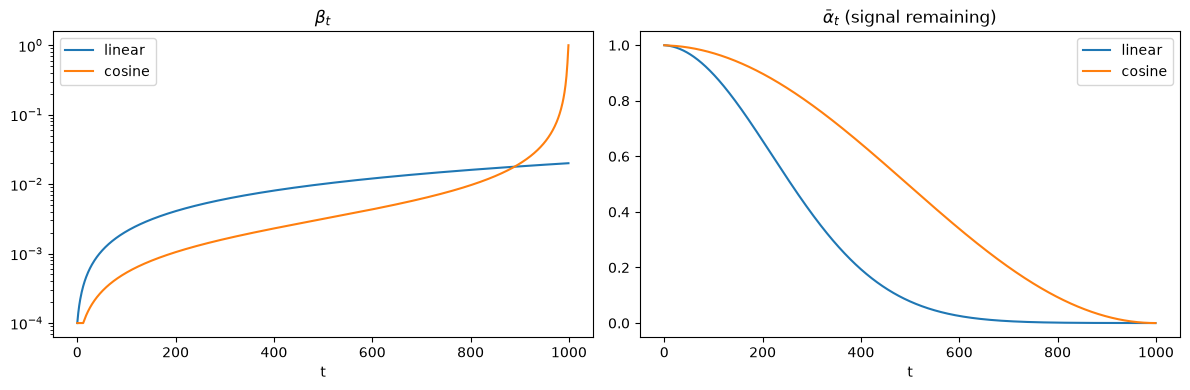

linear: alpha_bar at t=250: 0.521, t=500: 0.078, t=750: 0.0033, t=T-1: 4.04e-05
cosine: alpha_bar at t=250: 0.846, t=500: 0.492, t=750: 0.1431, t=T-1: 2.43e-09


In [8]:
schedules = {name: make_schedule(name, timesteps) for name in ['linear', 'cosine']}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, s in schedules.items():
    ax[0].plot(s['betas'].cpu(), label=name)
    ax[1].plot(s['alpha_bars'].cpu(), label=name)
ax[0].set_title(r'$\beta_t$'); ax[0].set_yscale('log'); ax[0].set_xlabel('t'); ax[0].legend()
ax[1].set_title(r'$\bar\alpha_t$ (signal remaining)'); ax[1].set_xlabel('t'); ax[1].legend()
plt.tight_layout(); plt.show()

for name, s in schedules.items():
    ab = s['alpha_bars'].cpu()
    print(f"{name:>6}: alpha_bar at t=250: {ab[250]:.3f}, t=500: {ab[500]:.3f}, t=750: {ab[750]:.4f}, t=T-1: {ab[-1]:.2e}")

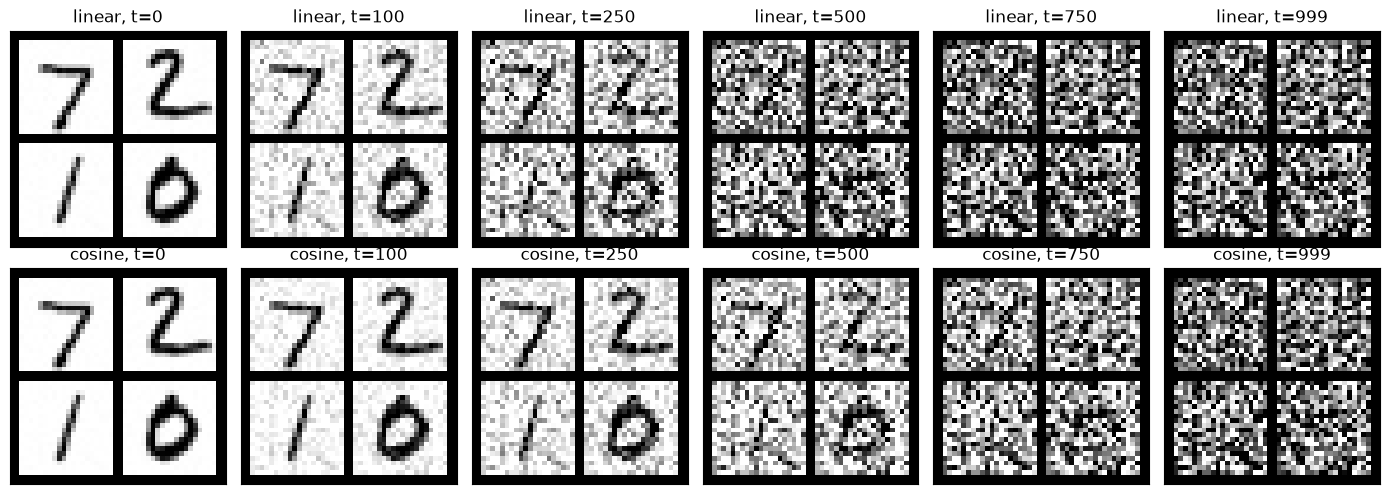

In [9]:
# Noised images at selected steps for both schedules
img = next(iter(DataLoader(test_dataset, batch_size=8, shuffle=False)))[0].to(device)
timesteps_investigated = [0, 100, 250, 500, 750, 999]
fig, ax = plt.subplots(2, len(timesteps_investigated), figsize=(14, 5))
torch.manual_seed(SEED)
noise = torch.randn_like(img)
for r, (name, s) in enumerate(schedules.items()):
    for c, tt in enumerate(timesteps_investigated):
        t = torch.full((img.shape[0],), tt, device=device, dtype=torch.long)
        noised = q_sample(img, t, s, noise=noise).clamp(-1, 1)
        ax[r, c].imshow(utils.make_grid((noised[:4] + 1) / 2, nrow=2).permute(1, 2, 0).cpu())
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
        ax[r, c].set_title(f'{name}, t={tt}')
plt.tight_layout(); plt.show()

## Backward diffusion process: conditional U-Net
Same architecture as the tutorial's `UNet_cond`. The class label is embedded with `nn.Embedding` and added to the time embedding.

In [10]:
channels = 1  # for MNIST (image_size is set from the data / checkpoints)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class UNet_cond(nn.Module):
    """Same architecture as the 9.3 tutorial. Only change: `timesteps` is stored on the model
    (instead of read from a global) so each checkpoint normalises t with its own T."""
    def __init__(self, ch=32, n_classes=10, timesteps=1000):
        super().__init__()
        self.timesteps = timesteps
        # encoder
        self.enc1 = ConvBlock(channels, ch)
        self.enc2 = ConvBlock(ch, ch*2)
        # bottleneck
        self.bot = ConvBlock(ch*2, ch*2)
        # decoder
        self.dec2 = ConvBlock(ch*2 + ch*2, ch)
        self.dec1 = ConvBlock(ch + ch, ch)
        # final
        self.final = nn.Conv2d(ch, channels, 1)

        # timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, ch),
            nn.ReLU(),
            nn.Linear(ch, ch)
        )

        # class embedding
        self.class_emb = nn.Embedding(n_classes, ch)

        # projections to match channel dims
        self.to_e1 = nn.Conv2d(ch, ch, 1)
        self.to_e2 = nn.Conv2d(ch, ch*2, 1)
        self.to_b  = nn.Conv2d(ch, ch*2, 1)
        self.to_d2 = nn.Conv2d(ch, ch, 1)
        self.to_d1 = nn.Conv2d(ch, ch, 1)

        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t, y):
        t = t.float().unsqueeze(-1) / self.timesteps
        t_emb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)

        y_emb = self.class_emb(y).unsqueeze(-1).unsqueeze(-1)

        cond_emb = t_emb + y_emb

        e1 = self.enc1(x) + self.to_e1(cond_emb)
        e2 = self.enc2(self.pool(e1)) + self.to_e2(cond_emb)

        b = self.bot(self.pool(e2)) + self.to_b(cond_emb)

        d2 = self.upsample(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2) + self.to_d2(cond_emb)

        d1 = self.upsample(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1) + self.to_d1(cond_emb)

        return self.final(d1)

## Training the models (Algorithm 1)
`train_cddpm` is the tutorial's conditional training loop wrapped in a function so it can be run once per schedule. The seed, model initialisation and mini-batch order (seeded `DataLoader` generator) are identical for both runs. Per-epoch mean loss and wall-clock time are recorded and saved in the checkpoint.

In [11]:
def train_cddpm(schedule_name, epochs=epochs):
    sched = schedules[schedule_name]
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)

    # define model and optimiser
    model = UNet_cond(ch=n_channels_unet, n_classes=n_class, timesteps=timesteps).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    g = torch.Generator().manual_seed(SEED)   # same mini-batch order for both schedules
    train_dataloader = DataLoader(train_dataset, batch_size=bs_train, shuffle=True, generator=g)

    epoch_losses, epoch_times = [], []
    runtime = time.time()
    for epoch in range(epochs):
        model.train()
        running, n_seen = 0.0, 0
        pbar = tqdm(iterable=train_dataloader, unit="batch", desc=f'[{schedule_name}] epoch {epoch+1}/{epochs}', colour='GREEN')
        for imgs, labels in pbar:
            imgs = imgs.to(device)
            labels = labels.to(device)

            batch_size = imgs.shape[0]
            t = torch.randint(0, timesteps, (batch_size,), device=device).long()
            noise = torch.randn_like(imgs)
            x_t = q_sample(imgs, t, sched, noise=noise)

            pred_noise = model(x_t, t, labels)
            loss = loss_fn(pred_noise, noise)

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item() * batch_size
            n_seen += batch_size
            pbar.set_postfix(loss=loss.item())
        pbar.close()
        epoch_losses.append(running / n_seen)
        epoch_times.append(time.time() - runtime)

    train_time = time.time() - runtime
    print(f'[{schedule_name}] Training time: {train_time:.2f} seconds, final epoch loss: {epoch_losses[-1]:.4f}')

    ckpt = {
        'model_state': model.state_dict(),
        'schedule': schedule_name,
        'T': timesteps,
        'ch': n_channels_unet,
        'n_classes': n_class,
        'image_size': image_size,
        'epochs': epochs,
        'lr': lr,
        'batch_size': bs_train,
        'seed': SEED,
        'epoch_losses': [float(l) for l in epoch_losses],
        'epoch_times_s': [float(s) for s in epoch_times],
        'train_time_s': float(train_time),
        'device': str(device),
    }
    path = os.path.join(CKPT_DIR, f'cddpm_{schedule_name}.pt')
    torch.save(ckpt, path)
    print('saved', path)
    return model, ckpt

### Model 1: linear schedule (baseline)

In [12]:
model_linear, ckpt_linear = train_cddpm('linear')

[linear] epoch 150/150: 100%|██████████| 469/469 [00:08<00:00, 55.43batch/s, loss=0.0267]


[linear] Training time: 1269.04 seconds, final epoch loss: 0.0282
saved checkpoints/cddpm_linear.pt


### Model 2: cosine schedule (hypothesis)

In [13]:
model_cosine, ckpt_cosine = train_cddpm('cosine')

[cosine] epoch 150/150: 100%|██████████| 469/469 [00:08<00:00, 55.35batch/s, loss=0.0445]


[cosine] Training time: 1270.27 seconds, final epoch loss: 0.0484
saved checkpoints/cddpm_cosine.pt


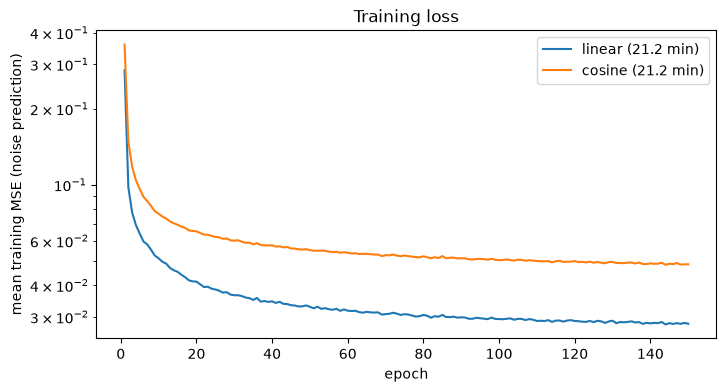

In [14]:
plt.figure(figsize=(8, 4))
for name, ck in [('linear', ckpt_linear), ('cosine', ckpt_cosine)]:
    plt.plot(range(1, len(ck['epoch_losses']) + 1), ck['epoch_losses'], label=f"{name} ({ck['train_time_s']/60:.1f} min)")
plt.xlabel('epoch'); plt.ylabel('mean training MSE (noise prediction)'); plt.yscale('log')
plt.title('Training loss'); plt.legend(); plt.show()

Note: the two loss curves are **not directly comparable** as a quality measure. Each schedule spends a different share of its timesteps at each noise level, and predicting the noise is easier at some noise levels than others. Sample quality is assessed in `main_report.ipynb`.

## Generate artificial digits (sanity check)

In [15]:
@torch.no_grad()
def p_sample_cDDPM(model, x_t, t_index, y, sched):
    """
    Single reverse step (Algorithm 2, DDPM) - as in the tutorial, but using the given schedule.
    t_index: scalar int (0..T-1) (all elements in batch have same t)
    """
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    beta = extract(sched['betas'], t, x_t.shape)
    alpha = extract(sched['alphas'], t, x_t.shape)
    alpha_bar = extract(sched['alpha_bars'], t, x_t.shape)
    sigma = torch.sqrt(beta)

    pred_noise = model(x_t, t, y)

    if t_index == 0:
        z = 0
    else:
        z = torch.randn_like(x_t)

    x_tm1 = 1/torch.sqrt(alpha) * (x_t - (1-alpha)/(torch.sqrt(1 - alpha_bar))*pred_noise) + sigma*z
    return x_tm1

@torch.no_grad()
def p_sample_loop_cDDPM(model, y, sched, seed=1337, show_progress=True):
    """Full ancestral sampling over all T steps of the schedule."""
    model.eval()
    torch.manual_seed(seed)
    n_samples = y.shape[0]
    x = torch.randn(n_samples, channels, image_size, image_size).to(device)  # x_T ~ N(0,I)
    T = sched['T']
    it = reversed(range(0, T))
    if show_progress:
        it = tqdm(it, desc=f"Sampling ({sched['name']}, {T} steps)", total=T, colour='BLUE')
    for t in it:
        x = p_sample_cDDPM(model, x, t, y, sched)
    return x.clamp(-1, 1)

@torch.no_grad()
def p_sample_loop_respaced(model, y, sched, n_steps, seed=1337, show_progress=False):
    """
    Sampling with FEWER steps than the model was trained with (timestep respacing,
    Nichol & Dhariwal 2021, Sec. 4). Keep n_steps evenly spaced timesteps of the original
    schedule, then recompute betas from alpha_bar so the noise levels stay consistent:
        beta'_i = 1 - alpha_bar[s_i] / alpha_bar[s_{i-1}]
    The network is still given the ORIGINAL timestep index s_i.
    With n_steps == T this reduces to p_sample_loop_cDDPM.
    """
    model.eval()
    torch.manual_seed(seed)
    T = sched['T']
    use_t = torch.linspace(0, T - 1, n_steps, device=device).round().long()
    ab = sched['alpha_bars'][use_t]
    ab_prev = torch.cat([torch.ones(1, device=device), ab[:-1]])
    new_betas = 1 - ab / ab_prev

    x = torch.randn(y.shape[0], channels, image_size, image_size).to(device)
    it = reversed(range(n_steps))
    if show_progress:
        it = tqdm(it, desc=f"Sampling ({sched['name']}, {n_steps} steps)", total=n_steps, colour='BLUE')
    for i in it:
        t = torch.full((y.shape[0],), int(use_t[i]), device=device, dtype=torch.long)
        beta, a_bar = new_betas[i], ab[i]
        pred_noise = model(x, t, y)
        x = (x - beta / torch.sqrt(1 - a_bar) * pred_noise) / torch.sqrt(1 - beta)
        if i > 0:
            x = x + torch.sqrt(beta) * torch.randn_like(x)
    return x.clamp(-1, 1)

In [16]:
def show_digit_grid(samples, n_per_row, row_labels, title, save_path=None):
    """samples in [-1,1]; one row per label."""
    grid = utils.make_grid((samples + 1) / 2, nrow=n_per_row, padding=2)
    plt.figure(figsize=(n_per_row * 0.9, len(row_labels) * 0.9 + 0.6))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    cell = image_size + 2
    plt.yticks([2 + cell * i + image_size / 2 for i in range(len(row_labels))], row_labels)
    plt.xticks([])
    plt.title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

Sampling (linear, 1000 steps): 100%|██████████| 1000/1000 [00:04<00:00, 215.92it/s]


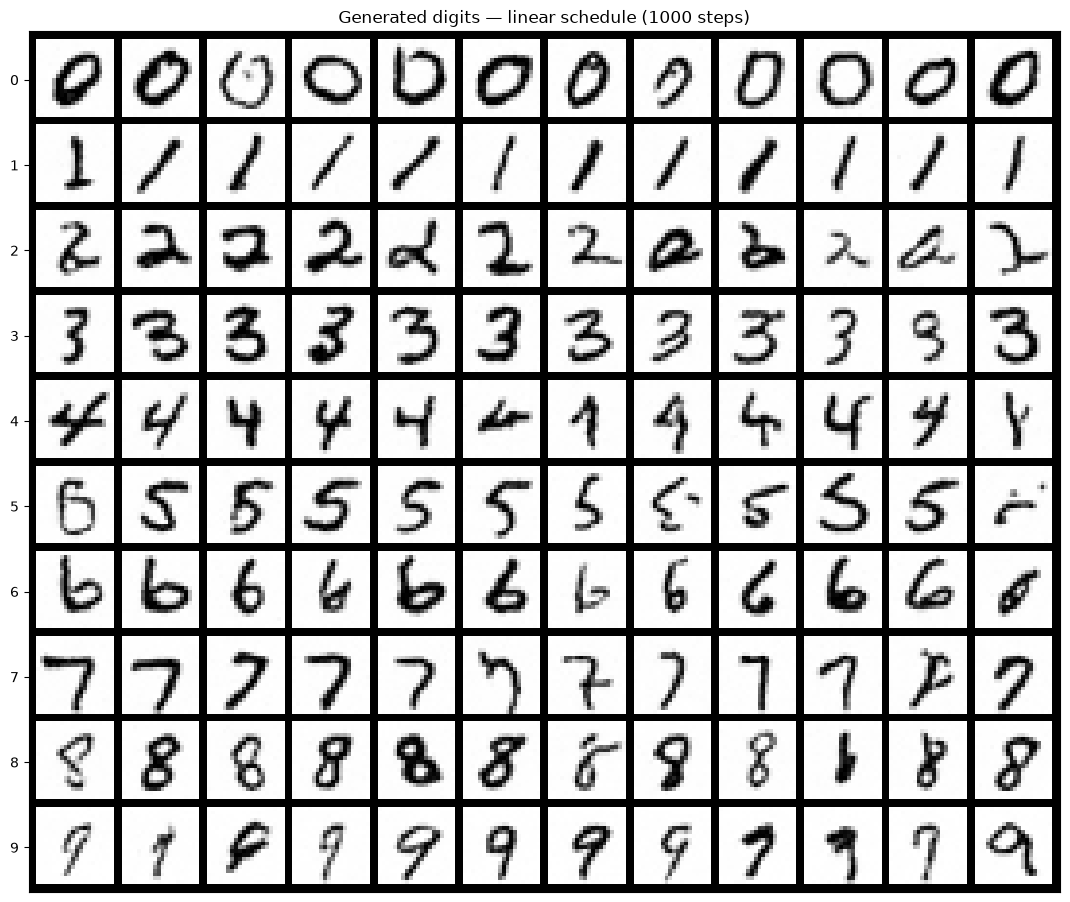

Sampling (cosine, 1000 steps): 100%|██████████| 1000/1000 [00:04<00:00, 216.34it/s]


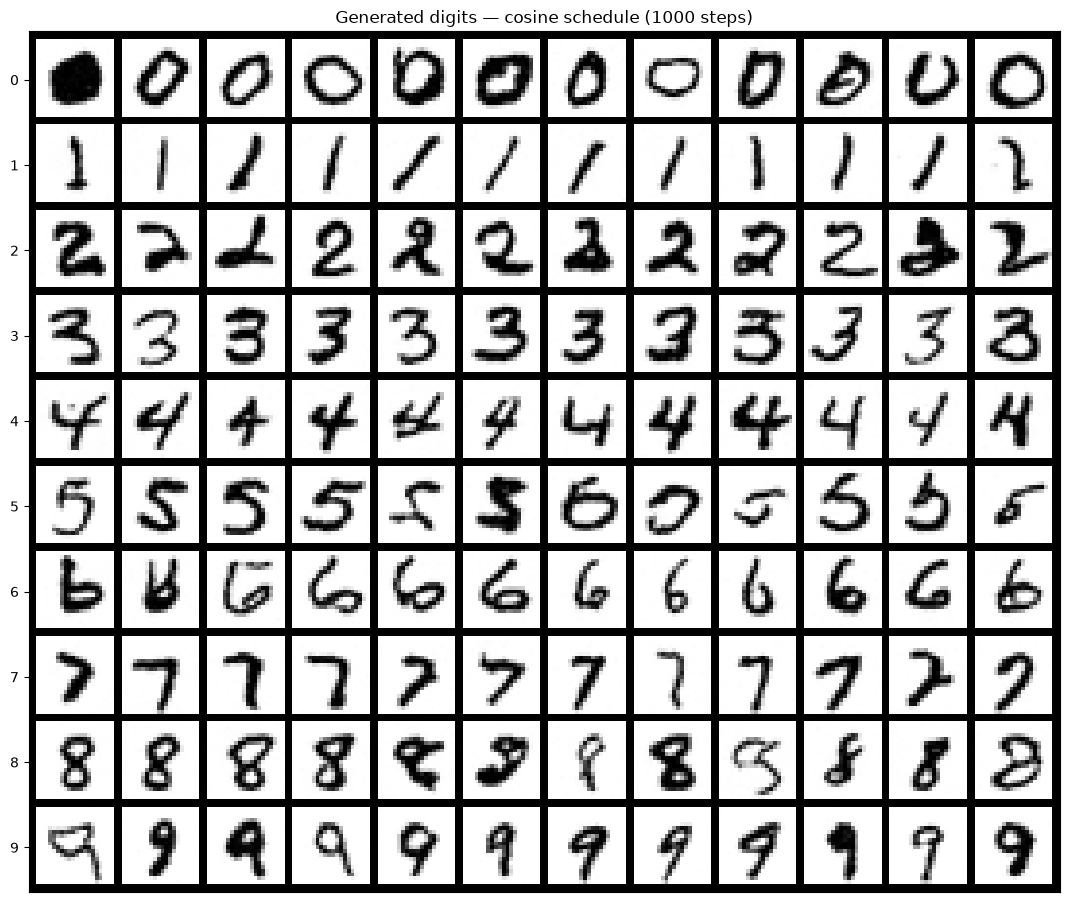

In [17]:
sample_per_class = 12
labels = torch.arange(0, 10).repeat_interleave(sample_per_class).to(device)
for name, model in [('linear', model_linear), ('cosine', model_cosine)]:
    samples = p_sample_loop_cDDPM(model, labels, schedules[name])
    show_digit_grid(samples, sample_per_class, list(range(10)), f'Generated digits — {name} schedule ({timesteps} steps)')

## Evaluation classifier
A small CNN trained on the same training set, used in `main_report.ipynb` to measure whether generated digits are recognisable as the requested class.

In [18]:
class DigitClassifier(nn.Module):
    """Small CNN used only as an automatic judge of generated digits (inputs in [-1, 1])."""
    def __init__(self, image_size=28):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * (image_size // 4) ** 2, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.head(self.features(x))

In [19]:
torch.manual_seed(SEED)
clf = DigitClassifier(image_size=image_size).to(device)
clf_opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
clf_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, generator=torch.Generator().manual_seed(SEED))
for epoch in range(5):
    clf.train()
    for x, y in tqdm(clf_loader, desc=f'classifier epoch {epoch+1}/5', colour='GREEN'):
        x, y = x.to(device), y.to(device)
        loss = F.cross_entropy(clf(x), y)
        clf_opt.zero_grad(); loss.backward(); clf_opt.step()

clf.eval()
correct = 0
with torch.no_grad():
    for x, y in test_dataloader:
        correct += (clf(x.to(device)).argmax(1).cpu() == y).sum().item()
clf_test_acc = correct / len(test_dataset)
print(f'Classifier test accuracy on real digits: {clf_test_acc:.4f}')

torch.save({'model_state': clf.state_dict(), 'test_acc': float(clf_test_acc), 'image_size': int(image_size)},
           os.path.join(CKPT_DIR, 'mnist_classifier.pt'))
print('saved', os.path.join(CKPT_DIR, 'mnist_classifier.pt'))

classifier epoch 5/5: 100%|██████████| 469/469 [00:01<00:00, 402.80it/s]


Classifier test accuracy on real digits: 0.9908
saved checkpoints/mnist_classifier.pt
